This notebook tests the ResNet-18 architecture on the KDEF dataset only.

The ResNet-18 model utilizes pre-trained weights, and the KDEF dataset is train throughout the networks layers.

Model Parameters:
* optimizer = Adam [lr = 0.001, weight_decay=0.01]
* loss function = Cross Entropy Loss (weights = None)

Early stopping is applied to combat overfitting. 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

from myDataset import *
from ArchitectureMethods import *
from MetricMethods import *


seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
print(os.getcwd())
os.chdir("..")
print(os.getcwd())
train_dataset = myDataset(directory = "DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers= 8 )
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers= 8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers= 8)



/user/HS401/ob00564/Documents/COM3001/KDEF/Transfer Learning
/user/HS401/ob00564/Documents/COM3001/KDEF
Train set length: 2350
Test set length: 294
Validation set length: 294


In [3]:
sorted_emotion_counts = train_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = val_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = test_dataset.getNoImagesInClass()
print(sorted_emotion_counts)

{'0': 336, '1': 336, '2': 336, '3': 336, '4': 335, '5': 335, '6': 336}
{'0': 42, '1': 42, '2': 42, '3': 42, '4': 42, '5': 42, '6': 42}
{'0': 42, '1': 42, '2': 42, '3': 42, '4': 42, '5': 42, '6': 42}


In [4]:
# @title Importing ResNet34 model, using DEFAULT weights
import torchvision.models as models
emotionTotal = 7
myModel = models.resnet18(weights = 'DEFAULT')
print(myModel)

# Freeze all layers
for param in myModel.parameters():
    param.requires_grad = False

for param in myModel.fc.parameters():
    param.requires_grad = True

# for param in myModel.layer4.parameters():
#     param.requires_grad = True

myModel.fc = nn.Sequential(nn.Linear(myModel.fc.in_features,emotionTotal))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
myModel.to(device)
print(device)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [5]:
import copy
# @title Training Loop
from tqdm import tqdm
# Loss function 
criterion = nn.CrossEntropyLoss()

# Optimizer
# optimizer = optim.SGD(myModel.parameters(), lr = 0.001, momentum=0.9, weight_decay= 0.01)
optimizer = optim.Adam(myModel.parameters(), lr = 0.00001, weight_decay=0.01)

train_losses, val_losses, train_accuracy, val_accuracy = train(myModel, device, train_loader, val_loader, optimizer, None, 100, criterion, 'KDEF/Transfer Learning/KDEF ResNet18 copy.pth')
y_true, y_pred, y_score = test(myModel, device, criterion, test_loader, 'Test')

100%|██████████| 147/147 [00:01<00:00, 75.72it/s]


Epoch 1/100, Training Loss: 2.0613, Validation Loss: 2.0320
Epoch 1/100, Training Acc: 15.433673469387754, Validation Accuracy: 18.092105263157894


100%|██████████| 147/147 [00:01<00:00, 84.68it/s] 


Epoch 2/100, Training Loss: 2.0003, Validation Loss: 2.0018
Epoch 2/100, Training Acc: 15.324344023323617, Validation Accuracy: 15.789473684210526


100%|██████████| 147/147 [00:01<00:00, 83.17it/s] 


...

Epoch 98/100, Training Loss: 1.3525, Validation Loss: 1.3662
Epoch 98/100, Training Acc: 58.27259475218659, Validation Accuracy: 50.10964912280702


100%|██████████| 147/147 [00:02<00:00, 71.68it/s]


Epoch 99/100, Training Loss: 1.3484, Validation Loss: 1.3595
Epoch 99/100, Training Acc: 57.9628279883382, Validation Accuracy: 51.42543859649123


100%|██████████| 147/147 [00:02<00:00, 72.85it/s]


Epoch 100/100, Training Loss: 1.3543, Validation Loss: 1.3599
Epoch 100/100, Training Acc: 57.15500485908649, Validation Accuracy: 53.39912280701755
Model saved successfully!
Test Loss: 1.4018, Test Accuracy: 53.74%


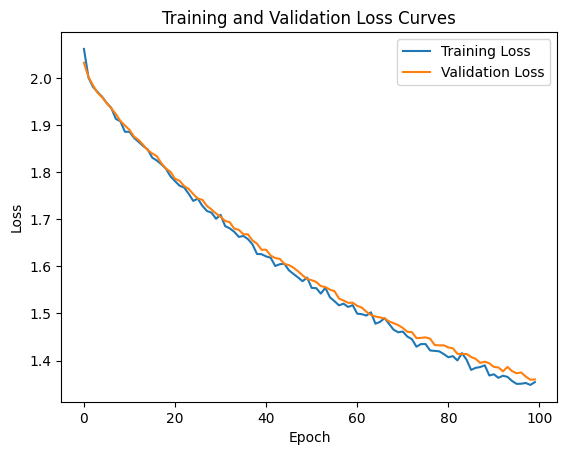

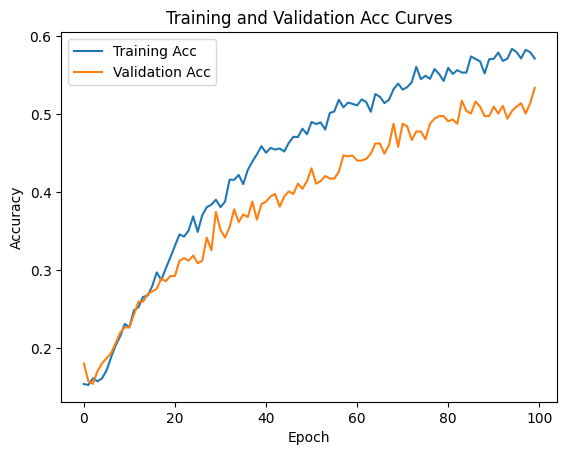

              precision    recall  f1-score   support

       Anger     0.4737    0.6429    0.5455        42
     Disgust     0.5833    0.5000    0.5385        42
        Fear     0.3214    0.2143    0.2571        42
   Happiness     0.6939    0.8095    0.7473        42
     Sadness     0.4231    0.2619    0.3235        42
    Surprise     0.5882    0.7143    0.6452        42
     Neurtal     0.5532    0.6190    0.5843        42

    accuracy                         0.5374       294
   macro avg     0.5195    0.5374    0.5202       294
weighted avg     0.5195    0.5374    0.5202       294



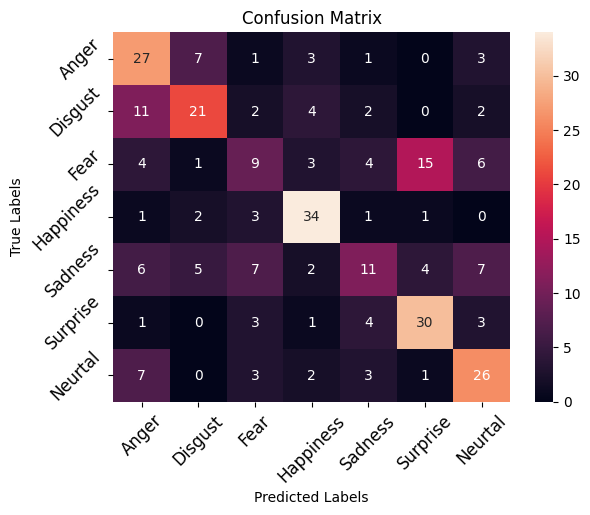

In [6]:
lossPlot(train_losses, val_losses)
accuracyPlot(train_accuracy, val_accuracy)
confusionMatrixPlot(y_true, y_pred)